# COVID-19 State-wise Data Analysis


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
covid_df = pd.read_csv("covid_19_india.csv")

# Data Cleaning

# Remove unnecessary columns
covid_df.drop(columns=["ConfirmedIndianNational", "ConfirmedForeignNational"], inplace=True)

# Fix inconsistent state names
covid_df['State/UnionTerritory'] = covid_df['State/UnionTerritory'].str.replace(r"\*+", "", regex=True)

covid_df['State/UnionTerritory'] = covid_df['State/UnionTerritory'].replace({
    'Karanataka': 'Karnataka',
    'Telengana': 'Telangana',
    'Himanchal Pradesh': 'Himachal Pradesh'
})

# Convert Date column to datetime
covid_df['Date'] = pd.to_datetime(covid_df['Date'], format="%d-%m-%Y")

In [4]:
# Feature Engineering

# Create Active Cases column
covid_df['Active_cases'] = covid_df['Confirmed'] - (covid_df['Deaths'] + covid_df['Cured'])

# State-wise Analysis (Pivot Table)

statewise = pd.pivot_table(
    covid_df,
    values=['Confirmed', 'Deaths', 'Cured'],
    index='State/UnionTerritory',
    aggfunc='max'
)

# Calculate Recovery Rate
statewise['Recovery_rate'] = statewise['Cured'] * 100 / statewise['Confirmed']

# Calculate Mortality Rate
statewise['Mortality_rate'] = statewise['Deaths'] * 100 / statewise['Confirmed']

# Sort by Confirmed cases
statewise = statewise.sort_values(by='Confirmed', ascending=False)

# Show styled table (for notebook view)
statewise.style.background_gradient(cmap='cubehelix')

,Confirmed,Cured,Deaths,Recovery_rate,Mortality_rate
State/UnionTerritory,,,,,
Maharashtra,6363442,6159676,134201,96.797865,2.108937
Kerala,3586693,3396184,18004,94.688450,0.501967
Karnataka,2921049,2861499,36848,97.961349,1.261465
Tamil Nadu,2579130,2524400,34367,97.877967,1.332504
Andhra Pradesh,1985182,1952736,13564,98.365591,0.683262
Uttar Pradesh,1708812,1685492,22775,98.635309,1.332797
West Bengal,1534999,1506532,18252,98.145471,1.189056
Delhi,1436852,1411280,25068,98.220276,1.744647
Chhattisgarh,1003356,988189,13544,98.488373,1.349870


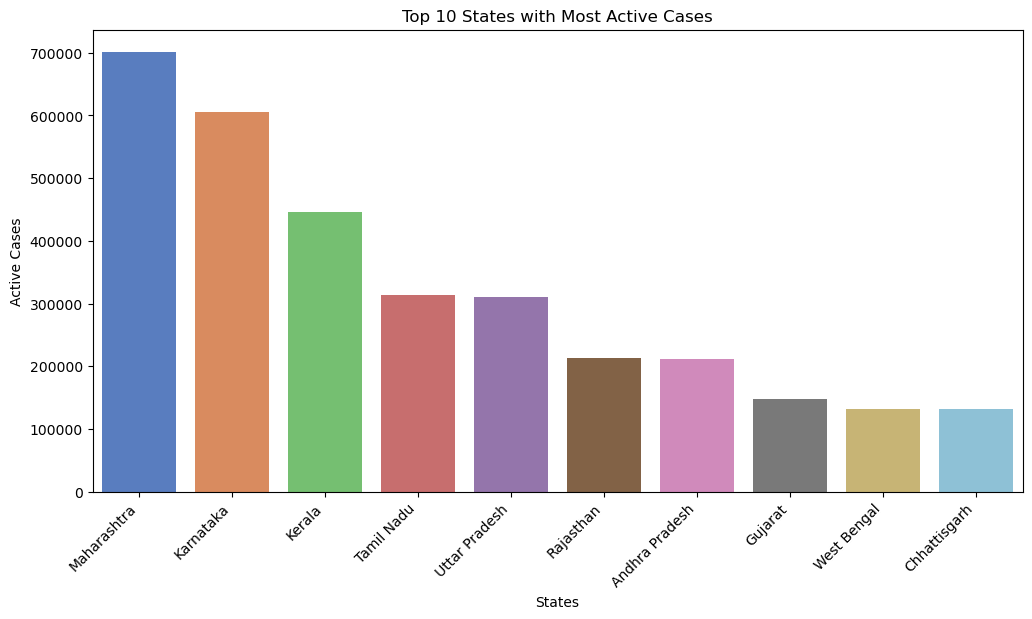

In [5]:
# Top 10 States by Active Cases

top_10_active_cases = covid_df.groupby('State/UnionTerritory').max()[['Active_cases']]
top_10_active_cases = top_10_active_cases.sort_values(by='Active_cases', ascending=False).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_10_active_cases.iloc[:10],
    x='State/UnionTerritory',
    y='Active_cases',
    hue='State/UnionTerritory',
    palette='muted',
    legend=False
)

plt.title("Top 10 States with Most Active Cases")
plt.xlabel("States")
plt.ylabel("Active Cases")
plt.xticks(rotation=45, ha='right')
plt.show()

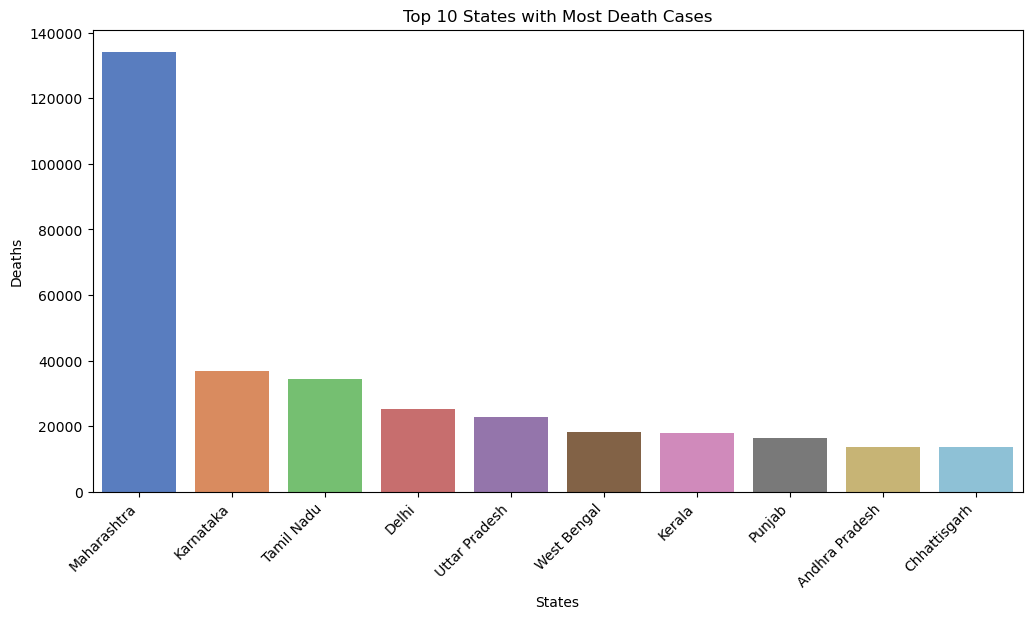

In [6]:
# Top 10 States by Death Cases

top_10_deaths = covid_df.groupby('State/UnionTerritory').max()[['Deaths']]
top_10_deaths = top_10_deaths.sort_values(by='Deaths', ascending=False).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_10_deaths.iloc[:10],
    x='State/UnionTerritory',
    y='Deaths',
    hue='State/UnionTerritory',
    palette='muted',
    legend=False
)

plt.title("Top 10 States with Most Death Cases")
plt.xlabel("States")
plt.ylabel("Deaths")
plt.xticks(rotation=45, ha='right')
plt.show()